In [ ]:
import pandas as pd
df = pd.read_csv("/content/xAPI-Edu-Data.csv")
df

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
data = pd.read_csv("xAPI-Edu-Data.csv")

# Input and output
X = data[["raisedhands"]]
y = data["Discussion"]

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Get input from user
raisedhands = float(input("Enter raisedhands: "))

# Predict Discussion
prediction = model.predict([[raisedhands]])

print("Predicted Discussion:", prediction[0])

Enter raisedhands: 10
Predicted Discussion: 32.07628110581713


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("xAPI-Edu-Data.csv")

# Male = 0, Female = 1
data["gender"] = data["gender"].map({"M": 0, "F": 1})

# Input and Output
X = data[["raisedhands"]]
y = data["gender"]

# Logistic Regression
model = LogisticRegression(class_weight="balanced")
model.fit(X, y)

# Input
raisedhands = float(input("Enter raisedhands: "))

# Prediction
prediction = model.predict([[raisedhands]])

print("Assigned Gender Value:", int(prediction[0]))

Enter raisedhands: 10
Assigned Gender Value: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = pd.read_csv("xAPI-Edu-Data.csv")

# Convert Topic
topic_values = {
    "Arabic": 0,
    "Biology": 1,
    "Chemistry": 2,
    "English": 3,
    "French": 4,
    "Geology": 5,
    "Geography": 6,
    "History": 7,
    "IT": 8,
    "Math": 9,
    "Quran": 10,
    "Science": 11,
    "Spanish": 12
}

data["Topic"] = data["Topic"].map(topic_values)

# Convert Class
data["Class"] = data["Class"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

# Convert StudentAbsenceDays
data["StudentAbsenceDays"] = data["StudentAbsenceDays"].map({
    "Under-7": 0,
    "Above-7": 1
})

# Convert output
data["ParentschoolSatisfaction"] = data["ParentschoolSatisfaction"].map({
    "Bad": 0,
    "Good": 1
})

# Input
X = data[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

# Output
y = data["ParentschoolSatisfaction"]

# Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

# User input
topic = input("Enter Topic: ")
raisedhands = float(input("Enter raisedhands: "))
discussion = float(input("Enter Discussion: "))

student_class = input("Enter Class (L/M/H): ")
absence = input("Enter StudentAbsenceDays (Under-7/Above-7): ")

# Convert Topic
topic = topic_values[topic]

# Convert Class
student_class = {
    "L": 0,
    "M": 1,
    "H": 2
}[student_class]

# Convert StudentAbsenceDays
absence = {
    "Under-7": 0,
    "Above-7": 1
}[absence]

# Prediction
prediction = model.predict([[
    topic,
    raisedhands,
    discussion,
    student_class,
    absence
]])

print("ParentschoolSatisfaction:", int(prediction[0]))

if prediction[0] == 0:
    print("Result: Bad")
else:
    print("Result: Good")

Enter Topic: IT
Enter raisedhands: 15
Enter Discussion: 20
Enter Class (L/M/H): L
Enter StudentAbsenceDays (Under-7/Above-7): Under-7
ParentschoolSatisfaction: 0
Result: Bad


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = pd.read_csv("xAPI-Edu-Data.csv")

# Convert Topic
topic_values = {
    "Arabic": 0,
    "Biology": 1,
    "Chemistry": 2,
    "English": 3,
    "French": 4,
    "Geology": 5,
    "Geography": 6,
    "History": 7,
    "IT": 8,
    "Math": 9,
    "Quran": 10,
    "Science": 11,
    "Spanish": 12
}

data["Topic"] = data["Topic"].map(topic_values)

# Convert Class
data["Class"] = data["Class"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

# Convert StudentAbsenceDays
data["StudentAbsenceDays"] = data["StudentAbsenceDays"].map({
    "Under-7": 0,
    "Above-7": 1
})

# Convert output
data["ParentschoolSatisfaction"] = data["ParentschoolSatisfaction"].map({
    "Bad": 0,
    "Good": 1
})

# Input
X = data[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

# Output
y = data["ParentschoolSatisfaction"]

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

# User input
topic = input("Enter Topic: ")
raisedhands = float(input("Enter raisedhands: "))
discussion = float(input("Enter Discussion: "))

student_class = input("Enter Class (L/M/H): ")
absence = input("Enter StudentAbsenceDays (Under-7/Above-7): ")

# Convert Topic
topic = topic_values[topic]

# Convert Class
student_class = {
    "L": 0,
    "M": 1,
    "H": 2
}[student_class]

# Convert StudentAbsenceDays
absence = {
    "Under-7": 0,
    "Above-7": 1
}[absence]

# Prediction
prediction = model.predict([[
    topic,
    raisedhands,
    discussion,
    student_class,
    absence
]])

print("ParentschoolSatisfaction:", int(prediction[0]))

if prediction[0] == 0:
    print("Result: Bad")
else:
    print("Result: Good")

Enter Topic: IT
Enter raisedhands: 15
Enter Discussion: 20
Enter Class (L/M/H): L
Enter StudentAbsenceDays (Under-7/Above-7): Under-7
ParentschoolSatisfaction: 0
Result: Bad


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
df.head(2)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M


Model Accuracy: 0.7395833333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.80        58
           1       0.71      0.58      0.64        38

    accuracy                           0.74        96
   macro avg       0.73      0.71      0.72        96
weighted avg       0.74      0.74      0.73        96


Enter Topic: IT
Enter raisedhands: 15
Enter Discussion: 20
Enter Class (L/M/H): L
Enter StudentAbsenceDays (Under-7/Above-7): Under-7

Predicted Parent School Satisfaction: Bad
Predicted Value: 1


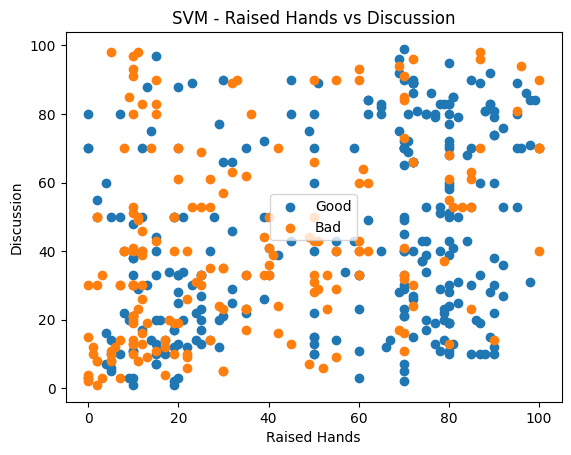

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
df = pd.read_csv("/content/xAPI-Edu-Data.csv")

# 2. Select input columns
X = df[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

# 3. Select output column
y = df["ParentschoolSatisfaction"]

# 4. Convert output into numbers
# Good = 0
# Bad = 1
y = y.map({
    "Good": 0,
    "Bad": 1
})

# 5. Convert categorical input columns into numbers
X = pd.get_dummies(
    X,
    columns=["Topic", "Class", "StudentAbsenceDays"]
)

# 6. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. Scale the input data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. Create SVM model
model = SVC()

# 9. Train model
model.fit(X_train, y_train)

# 10. Prediction
y_pred = model.predict(X_test)

# 11. Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 12. Give your own input
topic_input = input("\nEnter Topic: ")
raisedhands_input = float(input("Enter raisedhands: "))
discussion_input = float(input("Enter Discussion: "))
class_input = input("Enter Class (L/M/H): ")
absence_input = input("Enter StudentAbsenceDays (Under-7/Above-7): ")

# 13. Create new input DataFrame
new_data = pd.DataFrame({
    "Topic": [topic_input],
    "raisedhands": [raisedhands_input],
    "Discussion": [discussion_input],
    "Class": [class_input],
    "StudentAbsenceDays": [absence_input]
})

# 14. Convert categorical values
new_data = pd.get_dummies(
    new_data,
    columns=["Topic", "Class", "StudentAbsenceDays"]
)

# 15. Make columns same as original X
original_X = df[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

original_X = pd.get_dummies(
    original_X,
    columns=["Topic", "Class", "StudentAbsenceDays"]
)

new_data = new_data.reindex(
    columns=original_X.columns,
    fill_value=0
)

# 16. Scale new input
new_data = scaler.transform(new_data)

# 17. Predict
prediction = model.predict(new_data)

# 18. Display result
if prediction[0] == 0:
    satisfaction = "Good"
else:
    satisfaction = "Bad"

print("\nPredicted Parent School Satisfaction:", satisfaction)
print("Predicted Value:", prediction[0])


# ==================================================
# 19. SVM PLOT
# ==================================================

# Use original data for plotting
plot_data = df[[
    "raisedhands",
    "Discussion",
    "ParentschoolSatisfaction"
]].copy()

# Convert output into numbers
plot_data["ParentschoolSatisfaction"] = plot_data[
    "ParentschoolSatisfaction"
].map({
    "Good": 0,
    "Bad": 1
})

# Plot Good = 0
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["Discussion"],
    label="Good"
)

# Plot Bad = 1
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["Discussion"],
    label="Bad"
)

plt.xlabel("Raised Hands")
plt.ylabel("Discussion")
plt.title("SVM - Raised Hands vs Discussion")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
data = pd.read_csv("xAPI-Edu-Data.csv")

# Convert Topic
topic_values = {
    "Arabic": 0,
    "Biology": 1,
    "Chemistry": 2,
    "English": 3,
    "French": 4,
    "Geology": 5,
    "Geography": 6,
    "History": 7,
    "IT": 8,
    "Math": 9,
    "Quran": 10,
    "Science": 11,
    "Spanish": 12
}

data["Topic"] = data["Topic"].map(topic_values)

# Convert Class
data["Class"] = data["Class"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

# Convert StudentAbsenceDays
data["StudentAbsenceDays"] = data["StudentAbsenceDays"].map({
    "Under-7": 0,
    "Above-7": 1
})

# Convert output
data["ParentschoolSatisfaction"] = data["ParentschoolSatisfaction"].map({
    "Bad": 0,
    "Good": 1
})

# Input
X = data[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

# Output
y = data["ParentschoolSatisfaction"]

# KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

# User input
topic = input("Enter Topic: ")
raisedhands = float(input("Enter raisedhands: "))
discussion = float(input("Enter Discussion: "))
student_class = input("Enter Class (L/M/H): ")
absence = input("Enter StudentAbsenceDays (Under-7/Above-7): ")

# Convert Topic
topic = topic_values[topic]

# Convert Class
student_class = {
    "L": 0,
    "M": 1,
    "H": 2
}[student_class]

# Convert StudentAbsenceDays
absence = {
    "Under-7": 0,
    "Above-7": 1
}[absence]

# Prediction
prediction = model.predict([[
    topic,
    raisedhands,
    discussion,
    student_class,
    absence
]])

print("ParentschoolSatisfaction:", int(prediction[0]))

if prediction[0] == 0:
    print("Result: Bad")
else:
    print("Result: Good")

Enter Topic: IT
Enter raisedhands: 15
Enter Discussion: 20
Enter Class (L/M/H): L
Enter StudentAbsenceDays (Under-7/Above-7): Under-7
ParentschoolSatisfaction: 1
Result: Good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


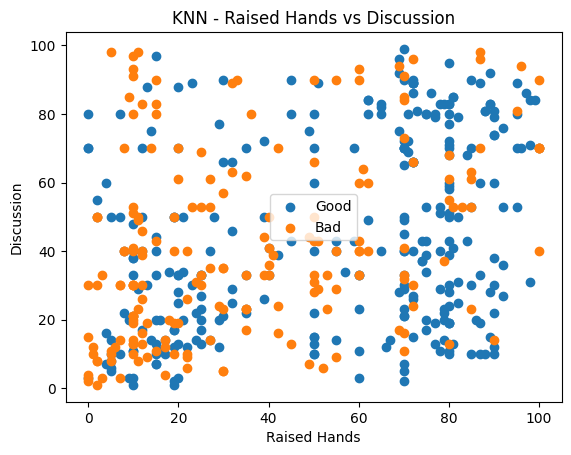

In [ ]:
import matplotlib.pyplot as plt


plot_data = df[[
    "raisedhands",
    "Discussion",
    "ParentschoolSatisfaction"
]].copy()

# Convert output into numbers
# Good = 0
# Bad = 1
plot_data["ParentschoolSatisfaction"] = plot_data[
    "ParentschoolSatisfaction"
].map({
    "Good": 0,
    "Bad": 1
})

# Plot Good = 0
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["Discussion"],
    label="Good"
)

# Plot Bad = 1
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["Discussion"],
    label="Bad"
)

plt.xlabel("Raised Hands")
plt.ylabel("Discussion")
plt.title("KNN - Raised Hands vs Discussion")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("/content/xAPI-Edu-Data.csv")


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
df = pd.read_csv("/content/xAPI-Edu-Data.csv")

# 2. Select input columns
X = df[[
    "Topic",
    "raisedhands",
    "Discussion",
    "Class",
    "StudentAbsenceDays"
]]

# 3. Select output column
y = df["ParentschoolSatisfaction"]

# 4. Convert output into numbers
# Good = 0
# Bad = 1
y = y.map({
    "Good": 0,
    "Bad": 1
})

# 5. Convert categorical input columns into numbers
X = pd.get_dummies(
    X,
    columns=["Topic", "Class", "StudentAbsenceDays"]
)

# 6. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. Create Naive Bayes model
model = GaussianNB()

# 8. Train model
model.fit(X_train, y_train)

# 9. Prediction
y_pred = model.predict(X_test)

# 10. Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. Give your own input
topic_input = input("\nEnter Topic: ")
raisedhands_input = float(input("Enter raisedhands: "))
discussion_input = float(input("Enter Discussion: "))
class_input = input("Enter Class (L/M/H): ")
absence_input = input("Enter StudentAbsenceDays (Under-7/Above-7): ")

# 12. Create new input DataFrame
new_data = pd.DataFrame({
    "Topic": [topic_input],
    "raisedhands": [raisedhands_input],
    "Discussion": [discussion_input],
    "Class": [class_input],
    "StudentAbsenceDays": [absence_input]
})

# 13. Convert categorical values
new_data = pd.get_dummies(
    new_data,
    columns=["Topic", "Class", "StudentAbsenceDays"]
)

# 14. Make columns same as training data
new_data = new_data.reindex(
    columns=X.columns,
    fill_value=0
)

# 15. Predict
prediction = model.predict(new_data)

# 16. Display result
if prediction[0] == 0:
    satisfaction = "Good"
else:
    satisfaction = "Bad"

print("\nPredicted Parent School Satisfaction:", satisfaction)
print("Predicted Value:", prediction[0])

Model Accuracy: 0.7395833333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77        58
           1       0.64      0.76      0.70        38

    accuracy                           0.74        96
   macro avg       0.73      0.74      0.73        96
weighted avg       0.75      0.74      0.74        96


Enter Topic: Math
Enter raisedhands: 15
Enter Discussion: 20
Enter Class (L/M/H): L
Enter StudentAbsenceDays (Under-7/Above-7): Under-7

Predicted Parent School Satisfaction: Bad
Predicted Value: 1


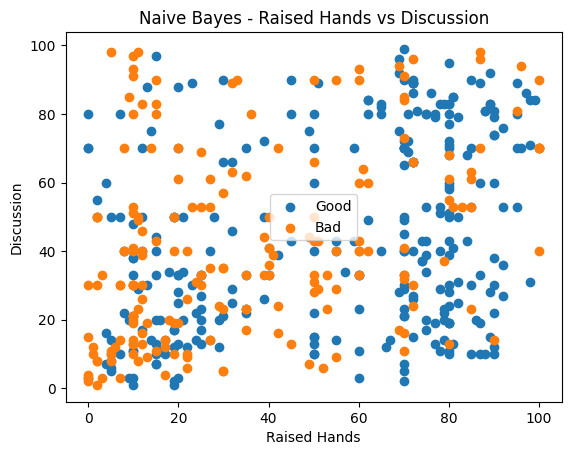

In [ ]:
# 17. Naive Bayes Plot

import matplotlib.pyplot as plt

# Create plotting data
plot_data = df[[
    "raisedhands",
    "Discussion",
    "ParentschoolSatisfaction"
]].copy()

# Convert output into numbers
# Good = 0
# Bad = 1
plot_data["ParentschoolSatisfaction"] = plot_data[
    "ParentschoolSatisfaction"
].map({
    "Good": 0,
    "Bad": 1
})

# Plot Good = 0
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 0]["Discussion"],
    label="Good"
)

# Plot Bad = 1
plt.scatter(
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["raisedhands"],
    plot_data[plot_data["ParentschoolSatisfaction"] == 1]["Discussion"],
    label="Bad"
)

plt.xlabel("Raised Hands")
plt.ylabel("Discussion")
plt.title("Naive Bayes - Raised Hands vs Discussion")
plt.legend()
plt.show()